In [1]:
!pip install datasets==3.6.0 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 10.2 MB/s eta 0:00:00


In [2]:
!pip install pysentimiento -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 20.4 MB/s eta 0:00:00


# Final Project

### Import Libraries

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score
from xgboost import XGBClassifier
from wordcloud import WordCloud


import pandas as pd
import matplotlib.pyplot as plt

In [4]:
from pysentimiento.preprocessing import preprocess_tweet

In [5]:
pip show huggingface_hub

Name: huggingface-hub
Version: 0.36.0
Summary: Client library to download and publish models, datasets and other repos on the huggingface.co hub
Home-page: https://github.com/huggingface/huggingface_hub
Author: Hugging Face, Inc.
Author-email: julien@huggingface.co
License: Apache
Location: /usr/local/lib/python3.12/dist-packages
Requires: filelock, fsspec, hf-xet, packaging, pyyaml, requests, tqdm, typing-extensions
Required-by: accelerate, datasets, diffusers, gradio, gradio_client, peft, sentence-transformers, timm, tokenizers, torchtune, transformers


In [6]:
import datasets
print(datasets.__version__)

3.6.0


In [7]:
# Full text cleaning
import re
#from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import openpyxl

In [8]:
import nltk
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to /root/nltk_data...


True

### Load the dataset

In [9]:
from datasets import load_dataset

ds = load_dataset("cardiffnlp/tweet_sentiment_multilingual", "english")
ds

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

tweet_sentiment_multilingual.py: 0.00B [00:00, ?B/s]

0000.parquet:   0%|          | 0.00/155k [00:00<?, ?B/s]

0000.parquet:   0%|          | 0.00/29.1k [00:00<?, ?B/s]

0000.parquet:   0%|          | 0.00/64.8k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1839 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/324 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/870 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 1839
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 324
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 870
    })
})

In [10]:
df_train=pd.DataFrame(ds['train'])
df_val=pd.DataFrame(ds['validation'])
df_test=pd.DataFrame(ds['test'])

combined_df = pd.concat([df_train, df_val, df_test], ignore_index=True)
print("Data shape:",combined_df.shape)
combined_df

Data shape: (3033, 2)


,text,label
0,okay i\u2019m sorry but TAYLOR SWIFT LOOKS NOT...,0
1,@user the DC comics site has Batman 44 release...,1
2,"""Frank Gaffrey\u002c Cliff May\u002c Steve Eme...",2
3,The tragedy of only thinking up hilarious twee...,0
4,"""Oliseh meets with Victor Moses in London: Sup...",1
...,...,...
3028,"""All 11 of the UK’s most senior judges will ta...",1
3029,@user #hatchimals #BlackFriday Count me in! 🍀,2
3030,American Radical Christianity seems to love ha...,0
3031,#ICYMI The #NBAwards winners for 2016 wereThe ...,1


### Cleaning

In [11]:
combined_df = combined_df.dropna(subset=['text']) #Removes empty values in the column "Text"
combined_df = combined_df.dropna(subset=['label']) #Removes empty values in the column "Label"
combined_df = combined_df.drop_duplicates(subset=['text'], keep='first') #Removes duplicate values in column #Text"
print(f"After removing NaN + exact duplicates: {combined_df.shape}")

After removing NaN + exact duplicates: (3033, 2)


In [12]:
# Standard procedure to process tweets
combined_df['text'] = combined_df['text'].apply(lambda x:preprocess_tweet(x, lang='en'))
combined_df['text'] = combined_df['text'].astype(str).apply(openpyxl.utils.escape.unescape)

# Remove special characters
combined_df['text'] = combined_df['text'].str.replace(r'&#\d{2};', '', regex=True)
combined_df['text'] = combined_df['text'].str.replace(r'&#\d{3};', '', regex=True)
combined_df['text'] = combined_df['text'].str.replace(r'&#\d{4};', '', regex=True)

# Use str.replace with the regex pattern to remove all matching sequences
pattern = r'\\u[0-9a-fA-F]{4}' # Matches \u followed by exactly 4 hex digits
combined_df['text'] = combined_df['text'].str.replace(pattern, '', regex=True)

In [13]:
# Keep only rows where 'text' contains at least one number
# Verifying whether numbers are important enough to keep when cleaning text
filtered_df = combined_df[combined_df['text'].str.contains(r'\d', na=False)]
filtered_df.sample(5)

,text,label
2509,Europe Canine Vaccines Market Report 2016 by R...,1
1955,"""I liked a @USER video John Cena lectures Nikk...",2
1560,Ghost Rider 2 sucks compared to the 1st my mom...,0
2960,Ludicrous road trip: Tesla Model S P90D from L...,2
677,Kendrick's was straight. But check out my boy ...,2


In [14]:
# str.lower: Lowercase
# str.replace: Remove characters that are not letters, such as numbers, special strings
# str.strip: Removes extra spaces at the start or end of the string.

normalized = combined_df['text'].str.lower()\
    .str.replace(r'[^a-z\s]', '', regex=True)\
    .str.strip()

normalized.sample(5)

,text
603,user so the thing next thursday isnt free youd...
2768,micha dorst took this beautiful picture inside...
2521,user reports brush fire nearing community of n...
20,fianlly gaming review of moto g and it is a so...
642,mihajlovic had dinner with berlusconi on frida...


In [15]:
# Find duplicates using hashing + exact match on cleaned version
duplicates_mask = normalized.duplicated(keep='first')
removed = duplicates_mask.sum() # Count how many duplicates will be removed
combined_df = combined_df[~duplicates_mask].reset_index(drop=True) # Removes duplicate rows using the duplicates mask and resets the DataFrame index
print(f"Removed {removed:,} near-duplicate / very similar tweets")
print(f"New shape: {combined_df.shape}")

Removed 0 near-duplicate / very similar tweets
New shape: (3033, 2)


In [16]:
#stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [17]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http[s]?://\S+', ' ', text)     # URLs
    text = re.sub(r'@\w+', ' ', text)               # mentions
    text = re.sub(r'#(\w+)', r'\1', text)           # hashtags → keep word
    text = re.sub(r'hashtag', r' ', text)           # hashtags → keep word
    #text = re.sub(r'[^a-z\s]', ' ', text)           # keep only letters
    text = re.sub(r'\s+', ' ', text).strip()
    words = [lemmatizer.lemmatize(w) for w in text.split() if len(w)>3]
    return ' '.join(words)


In [18]:
print("Applying text cleaning...")
combined_df['cleaned_text'] = combined_df['text'].apply(clean_text) #I'm creating a new column where I'll store the data cleaned

# Drop empty rows after cleaning
before = len(combined_df)
combined_df = combined_df[combined_df['cleaned_text'].str.len() > 0].reset_index(drop=True)
print(f"Removed {before-len(combined_df)} empty texts → Final rows: {len(combined_df):,}")
combined_df.sample(5)

Applying text cleaning...
Removed 0 empty texts → Final rows: 3,033


,text,label,cleaned_text
1051,Conor McGregor was reportedly fight with a bad...,1,conor mcgregor reportedly fight with knee satu...
3025,Ricktatorship by TheMeeDes hashtag art hashtag...,1,ricktatorship themeedes illustration popcultur...
1258,Why in the world is Jeb Bush embracing Eric Ca...,1,world bush embracing eric cantor?: answer simp...
2363,"Thankful for my fam, the slores, house3, tswif...",2,"thankful fam, slores, house3, tswift, grayson ..."
1572,Dammn yung Tracy McGrady goin to play in China...,0,dammn yung tracy mcgrady goin play china reall...


In [19]:
# Preview
print("Sample cleaned tweets:\n" + "—"*80)
for i in range(3):
    print(f"Raw     : {combined_df['text'].iloc[i]}")
    print(f"Cleaned : {combined_df['cleaned_text'].iloc[i]}\n")

Sample cleaned tweets:
————————————————————————————————————————————————————————————————————————————————
Raw     : okay im sorry but TAYLOR SWIFT LOOKS NOTHING LIKE JACKIE O SO STOP COMPARING THE TWO. cmon America arent you sick of her yet? (sorry)
Cleaned : okay sorry taylor swift look nothing like jackie stop comparing two. cmon america arent sick yet? (sorry)

Raw     : @USER the DC comics site has Batman 44 releases on the 9th but its out now?
Cleaned : comic site batman release now?

Raw     : "Frank Gaffrey Cliff May Steve Emerson: Brilliant. \"""Looming Threats: Iran Hezbollah Hamas\""" is the best hashtag cufidc session Ive had thus far."
Cleaned : "frank gaffrey cliff steve emerson: brilliant. \"""looming threats: iran hezbollah hamas\""" best cufidc session thus far."



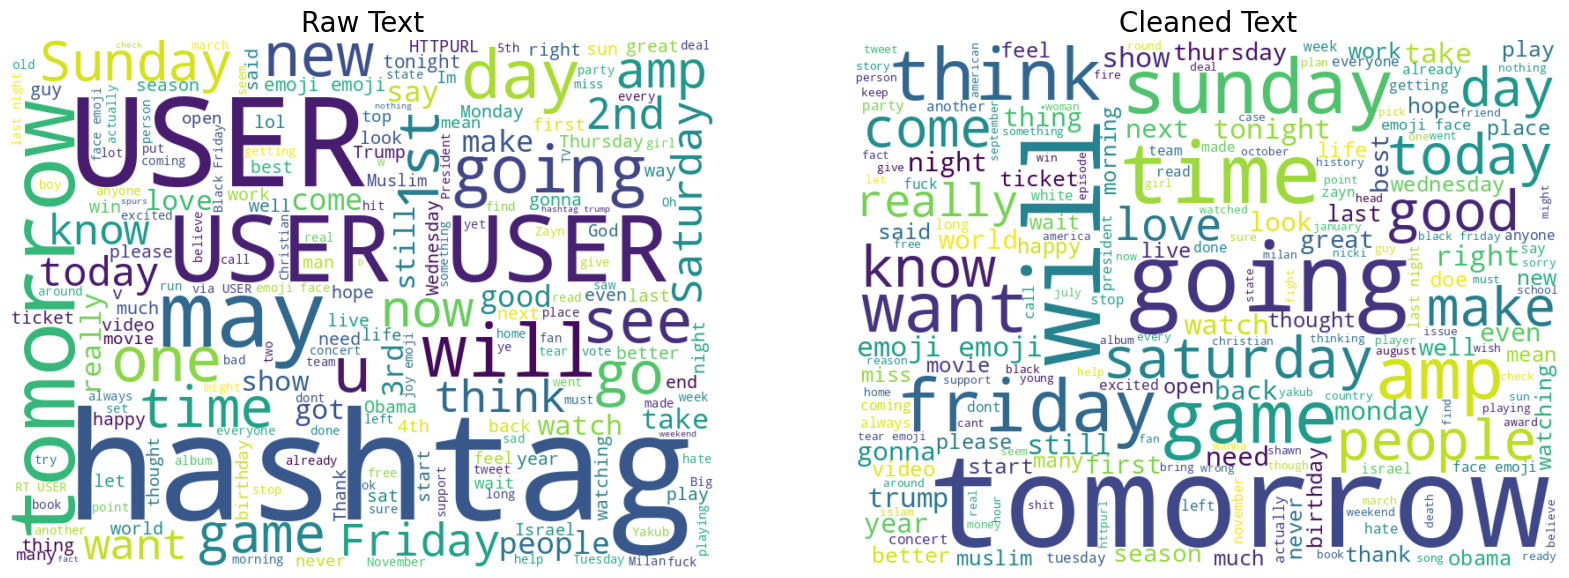

In [20]:
# Word clouds
fig, ax = plt.subplots(1,2,figsize=(20,8))

WordCloud(width=800,height=600,background_color='white')\
    .generate(' '.join(combined_df['text'])).to_image()
ax[0].imshow(WordCloud(width=800,height=600,background_color='white')
             .generate(' '.join(combined_df['text'])), interpolation='bilinear')
ax[0].set_title('Raw Text', fontsize=20)
ax[0].axis('off')

ax[1].imshow(WordCloud(width=800,height=600,background_color='white')
             .generate(' '.join(combined_df['cleaned_text'])), interpolation='bilinear')
ax[1].set_title('Cleaned Text', fontsize=20)
ax[1].axis('off')
plt.show()

### Data split

In [21]:
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(combined_df['cleaned_text'])

X = tfidf_matrix  # Keep as sparse
y = combined_df['label']

#Split data into train, validation and testing
X_train, X_temp, y_train, Y_temp = train_test_split(X,y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test= train_test_split(X_temp, Y_temp, test_size=0.5, random_state=42)

### Train and Evaluate models

#### Random forest

In [22]:
# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test)

# Evaluate
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {accuracy_rf:.2f}")

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.40      0.49       157
           1       0.42      0.64      0.51       148
           2       0.58      0.50      0.54       150

    accuracy                           0.51       455
   macro avg       0.54      0.51      0.51       455
weighted avg       0.54      0.51      0.51       455

Random Forest Accuracy: 0.51


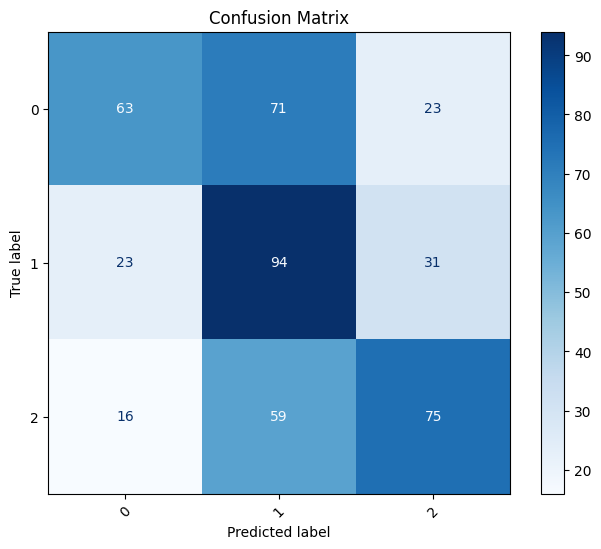

In [23]:
#  Confusion matrix
plt.figure(figsize=(8,6))
cm = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(cm, display_labels=sorted(y.unique()))\
    .plot(cmap='Blues', ax=plt.gca())
plt.title('Confusion Matrix')
plt.xticks(rotation=45)
plt.show()

In [24]:
# Train XGBoost classifier
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

xgb_model.fit(X_train, y_train)

# Predict
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate
print("XGBoost Classification Report:")
print(classification_report(y_test, y_pred_xgb))
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"XGBoost Accuracy: {accuracy_xgb:.2f}")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [06:19:11] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.45      0.50       157
           1       0.41      0.59      0.49       148
           2       0.63      0.49      0.55       150

    accuracy                           0.51       455
   macro avg       0.54      0.51      0.52       455
weighted avg       0.54      0.51      0.52       455

XGBoost Accuracy: 0.51


In [25]:
# # Train Logistic Regression
# logreg_model = LogisticRegression(
#     max_iter=1000,
#     random_state=42
# )
# logreg_model.fit(X_train, y_train)

# # Predict
# y_pred_lr = logreg_model.predict(X_test)

# # Evaluate
# print("Logistic Regression Classification Report:")
# print(classification_report(y_test, y_pred_logreg))
# accuracy_lr = accuracy_score(y_test, y_pred_logreg)
# print(f"Logistic Regression Accuracy: {accuracy_logreg:.2f}")

In [26]:
# #Comparison metrics
# # Random Forest
# precision_rf = precision_score(y_test, y_pred_rf, average='weighted')
# recall_rf = recall_score(y_test, y_pred_rf, average='weighted')
# f1_rf = f1_score(y_test, y_pred_rf, average='weighted')

# # XGBoost
# precision_xgb = precision_score(y_test, y_pred_xgb, average='weighted')
# recall_xgb = recall_score(y_test, y_pred_xgb, average='weighted')
# f1_xgb = f1_score(y_test, y_pred_xgb, average='weighted')

# #Logistic Regresion
# precision_lr = precision_score(y_test, y_pred_lr, average='weighted')
# recall_lr = recall_score(y_test, y_pred_lr, average='weighted')
# f1_lr = f1_score(y_test, y_pred_lr, average='weighted')

# metrics = pd.DataFrame({
#     "Model": ["Random Forest", "XGBoost", "Logistic Regression"],
#     "Accuracy": [accuracy_rf, accuracy_xgb, accuracy_lr],
#     "Precision": [precision_rf, precision_xgb, precision_lr],
#     "Recall": [recall_rf, recall_xgb, recall_lr],
#     "F1-Score": [f1_rf, f1_xgb, f1_lr]
# })

# metrics

In [27]:
from transformers import AutoTokenizer
from transformers import AutoModelForSequenceClassification, Trainer, TrainingArguments
import torch

import numpy as np

In [28]:
LR = 2e-5
EPOCHS = 1
BATCH_SIZE = 32
#MODEL = "cardiffnlp/twitter-xlm-roberta-base" # use this to finetune the language model
MODEL = "cardiffnlp/twitter-xlm-roberta-base-sentiment" # use this to finetune the sentiment classifier
MAX_TRAINING_EXAMPLES = -1 # set this to -1 if you want to use the whole training set

In [29]:
tokenizer = AutoTokenizer.from_pretrained(MODEL, use_fast=True)

config.json:   0%|          | 0.00/841 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

In [30]:
#X_train, X_val, X_test, y_train, y_val, y_test

In [31]:
combined_df['cleaned_text']

,cleaned_text
0,okay sorry taylor swift look nothing like jack...
1,comic site batman release now?
2,"""frank gaffrey cliff steve emerson: brilliant...."
3,tragedy only thinking hilarious tweet summer o...
4,"""oliseh meet with victor moses london: super e..."
...,...
3028,"""all most senior judge will take their seat su..."
3029,hatchimals black friday count emoji four leaf ...
3030,american radical christianity seems love hate-...
3031,icymi nbawards winner 2016 werethe underground...


In [32]:
# Split the original dataframe to maintain text alignment
train_df, temp_df, y_train, y_temp = train_test_split(
    combined_df['cleaned_text'], combined_df['label'], test_size=0.3, random_state=42
)
val_df, test_df, y_val, y_test = train_test_split(
    temp_df, y_temp, test_size=0.5, random_state=42
)

# Create dataset dictionary with text splits
dataset_dict = {
    'train': {
        'text': train_df.tolist(),
        'labels': y_train.tolist()  # if you need original labels
    },
    'val': {
        'text': val_df.tolist(),
        'labels': y_val.tolist()
    },
    'test': {
        'text': test_df.tolist(),
        'labels': y_test.tolist()
    }
}

# Now use your existing tokenizer code
train_encodings = tokenizer(dataset_dict['train']['text'], truncation=True, padding=True)
val_encodings = tokenizer(dataset_dict['val']['text'], truncation=True, padding=True)
test_encodings = tokenizer(dataset_dict['test']['text'], truncation=True, padding=True)

In [33]:
class MyDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = MyDataset(train_encodings, dataset_dict['train']['labels'])
val_dataset = MyDataset(val_encodings, dataset_dict['val']['labels'])
test_dataset = MyDataset(test_encodings, dataset_dict['test']['labels'])

In [34]:
training_args = TrainingArguments(
    output_dir='./results',                   # output directory
    num_train_epochs=EPOCHS,                  # total number of training epochs
    per_device_train_batch_size=BATCH_SIZE,   # batch size per device during training
    per_device_eval_batch_size=BATCH_SIZE,    # batch size for evaluation
    warmup_steps=100,                         # number of warmup steps for learning rate scheduler
    weight_decay=0.01,                        # strength of weight decay
    logging_dir='./logs',                     # directory for storing logs
    logging_steps=10,                         # when to print log
    #load_best_model_at_end=True,              # load or not best model at the end
)

num_labels = len(set(dataset_dict["train"]["labels"]))
model = AutoModelForSequenceClassification.from_pretrained(MODEL, num_labels=num_labels)

pytorch_model.bin:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

In [35]:
import wandb
wandb.init(mode="disabled")

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)


In [36]:
trainer = Trainer(
    model=model,                              # the instantiated 🤗 Transformers model to be trained
    args=training_args,                       # training arguments, defined above
    train_dataset=train_dataset,              # training dataset
    eval_dataset=val_dataset                  # evaluation dataset
)

trainer.train()

{'loss': 0.8211, 'grad_norm': 9.26479434967041, 'learning_rate': 4.5e-06, 'epoch': 0.14925373134328357}
{'loss': 0.7664, 'grad_norm': 7.311439514160156, 'learning_rate': 9.5e-06, 'epoch': 0.29850746268656714}
{'loss': 0.8525, 'grad_norm': 15.36256217956543, 'learning_rate': 1.45e-05, 'epoch': 0.44776119402985076}
{'loss': 0.7418, 'grad_norm': 9.463946342468262, 'learning_rate': 1.9500000000000003e-05, 'epoch': 0.5970149253731343}
{'loss': 0.7059, 'grad_norm': 10.85562515258789, 'learning_rate': 2.45e-05, 'epoch': 0.746268656716418}
{'loss': 0.8161, 'grad_norm': 9.899930953979492, 'learning_rate': 2.95e-05, 'epoch': 0.8955223880597015}
{'train_runtime': 141.2582, 'train_samples_per_second': 15.029, 'train_steps_per_second': 0.474, 'train_loss': 0.7711718046843116, 'epoch': 1.0}


TrainOutput(global_step=67, training_loss=0.7711718046843116, metrics={'train_runtime': 141.2582, 'train_samples_per_second': 15.029, 'train_steps_per_second': 0.474, 'train_loss': 0.7711718046843116, 'epoch': 1.0})

In [37]:
trainer.save_model("./results/best_model") # save best model

In [39]:
test_preds_raw, test_labels , _ = trainer.predict(test_dataset)
test_preds = np.argmax(test_preds_raw, axis=-1)
print(classification_report(test_labels, test_preds, digits=3))
accuracy_xlm_t = accuracy_score(test_labels, test_preds)
print(f"XML-T Accuracy: {accuracy_xlm_t:.2f}")

              precision    recall  f1-score   support

           0      0.754     0.841     0.795       157
           1      0.683     0.466     0.554       148
           2      0.693     0.827     0.754       150

    accuracy                          0.714       455
   macro avg      0.710     0.711     0.701       455
weighted avg      0.711     0.714     0.703       455

XML-T Accuracy: 0.71


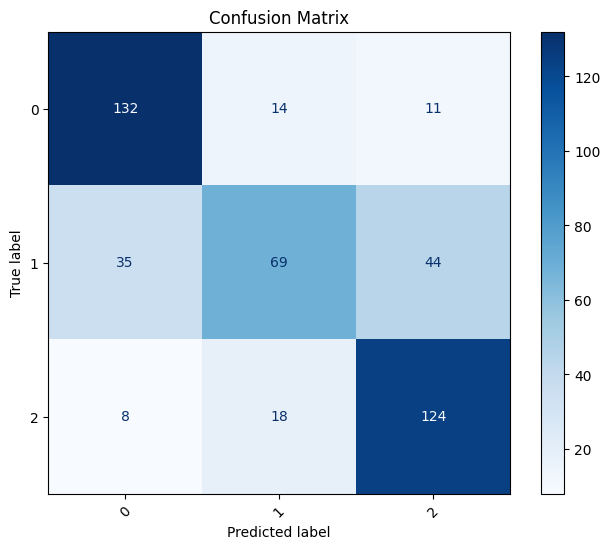

In [41]:
#  Confusion matrix
plt.figure(figsize=(8,6))
cm = confusion_matrix(test_labels, test_preds)
ConfusionMatrixDisplay(cm, display_labels=sorted(y.unique()))\
    .plot(cmap='Blues', ax=plt.gca())
plt.title('Confusion Matrix')
plt.xticks(rotation=45)
plt.show()

In [40]:
!zip -r /content/results.zip /content/results/

  adding: content/results/ (stored 0%)
  adding: content/results/checkpoint-67/ (stored 0%)
  adding: content/results/checkpoint-67/training_args.bin (deflated 53%)
  adding: content/results/checkpoint-67/rng_state.pth (deflated 26%)
  adding: content/results/checkpoint-67/config.json (deflated 52%)
  adding: content/results/checkpoint-67/scheduler.pt (deflated 61%)
  adding: content/results/checkpoint-67/trainer_state.json (deflated 65%)
  adding: content/results/checkpoint-67/optimizer.pt (deflated 70%)
  adding: content/results/checkpoint-67/model.safetensors (deflated 7%)
  adding: content/results/best_model/ (stored 0%)
  adding: content/results/best_model/training_args.bin (deflated 53%)
  adding: content/results/best_model/config.json (deflated 52%)
  adding: content/results/best_model/model.safetensors (deflated 7%)
